# Hybrid Quantum-Classical Reinforcement Learning (3/3)

___
___

## Introduction
___

This series of experiments is based on the 2025 paper by Nagy et al.: "[Hybrid Quantum-Classical Reinforcement Learning in Latent Observation Spaces](https://arxiv.org/abs/2410.18284)".

In this article, the authors apply hybrid quantum-classical Reinforcement Learning (RL) models to two simulated environments. They compare classical, qubit-based and photonic-based agents, all using Proximal Policy Optimization (PPO). They also use an AutoEncoder (AE) to compress the dimensionality of the observations and train that AE jointly with the PPO agents.

The notebook series aims to compare the resources cost of the different systems to reach the same performance. It is divided in three parts:

- [Part I: Classical vs Qubit agents on the Cart Pole environment](QRL_experiment_1.ipynb)
- [Part II: Classical vs Qubit agents on the Lunar Lander and Maze environments](QRL_experiment_2.ipynb)
- **Part III: Photonic agents on the three environments**

This third notebook will present:
1. Photonic-based PPO
2. Results on Cart Pole
3. Results on Lunar Lander
4. Results on Maze
5. Conclusion

*Note: This notebook was run on an Intel Core procesor i9-14900K (3.20 GHz) and an NVIDIA GeForce RTX 4090*

In [1]:
# Uncomment the following line to install the required dependencies
# !pip install ipynb setuptools==77.0.3 torch torchvision gymnasium swig "gymnasium[box2d]" matplotlib autoray==0.7.2 scipy==1.13.0 pennylane==0.29.1 StrawberryFields==0.23.0 PennyLane-SF==0.29.1

In [1]:
import os
import random
import numpy as np
import torch
import torch.nn as nn
import gymnasium as gym
import pennylane as qp

# Import from other files in the directory
from MazeEnvironment import Maze
from ipynb.fs.defs.QRL_experiment_1 import AutoEncoder, PPO, CriticNN, MemoryTracker, load_weights, load_results, plot_results
from ipynb.fs.defs.QRL_experiment_2 import ConvolutionalAE, MazePPO, CriticCNN

# For reproducibility
seed = 42
random.seed(seed)
np.random.seed(seed)
torch.manual_seed(seed)
if torch.cuda.is_available():
    torch.cuda.manual_seed(seed)

# Code works on CPU and GPU
device = torch.device(
    "cuda" if torch.cuda.is_available() else
    "cpu"
)

# The results are saved in qrl_results/qrl_results.json
results_folder = "qrl_results"
os.makedirs(results_folder, exist_ok=True)
results_filename = "qrl_results.json"

## 1 - Photonic-based PPO
___

The photonic version of PPO uses a continuous-variable (CV) quantum circuit, where information is encoded in the quantum states of optical modes rather than qubits. The photonic quantum circuit used in the article is composed of squeezing, displacement, rotation, and Kerr gates.

<div align="center">
<img src="images/qrl_demo_cvqnn.png" width="600"/>
</div>

The Kerr gate introduces the non-linearity required by the circuit. To run this implementation, we use the Strawberry Fields backend with a deprecated version of PennyLane that still supports the Kerr gate.

In [2]:
class ActorPhotonicNN(nn.Module):
    ''' A trainable photonic circuit for the Actor '''
    def __init__(self, input_shape, intermediate_dim, output_dim, device):
        super().__init__()
        self.device = device
        n_modes = max(1, input_shape//8)
        n_layers = intermediate_dim

        # A photonic trainable layer contains 11 weights
        shapes = qp.CVNeuralNetLayers.shape(n_layers=n_layers, n_wires=n_modes)
        weight_shapes = {
            name: shape for name, shape in zip(
                ["theta_1", "phi_1", "varphi_1", "r", "phi_r",
                 "theta_2", "phi_2", "varphi_2", "a", "phi_a", "k"],
                shapes,
            )
        }
        
        # The circuit with a strawberry-fields backend
        dev = qp.device("strawberryfields.fock", wires=n_modes, cutoff_dim=10)
        @qp.qnode(dev, interface="torch")
        def qnode(inputs, **weights):
            for wire in range(n_modes):
                # Initial squeezing
                qp.Squeezing(1/2, np.pi/2, wires=wire)
            # Displacement encoding
            qp.templates.embeddings.DisplacementEmbedding(inputs, wires=range(n_modes))
            # Parametric layers
            qp.CVNeuralNetLayers(*weights.values(), wires=range(n_modes))
            return [qp.expval(qp.X(i)) for i in range(n_modes)]
        
        # Qumodes are very costly so a first linear layer will further compress the AE's latent representation
        self.layer1 = nn.Linear(input_shape, n_modes).to(self.device)
        # The circuit is wrapped as a PyTorch layer
        self.qlayer = qp.qnn.TorchLayer(qnode, weight_shapes)
        # A regular dense layer is added at the end to output the actions
        self.layer2 = nn.Linear(n_modes, output_dim).to(self.device)

    def forward(self, x):
        x = self.layer1(x)
        x = self.qlayer(x.cpu()).to(self.device) # The quantum layer cannot run on GPU
        return self.layer2(x)

## 2 - Results on Cart Pole

In [ ]:
# Create the environment
cartpole_env = gym.make("CartPole-v1", render_mode="rgb_array")
cartpole_env.reset(seed=seed)
cartpole_env.action_space.seed(seed)
cartpole_env.observation_space.seed(seed)
env_name = "Cart Pole"

# Create the config
cp_config = {
    "ae_hidden_dim": 32, "ae_output_dim": 2,
    "critic_intermediate_dim": 64, "minibatch_size": 128, "lr": 1e-3,
    "K": 10, "episode_update_frequency": 1, "mean_reward_lookback": 20, "mean_reward_stop": 480,
    "gamma": 0.98, "lambda": 0.8, "epsilon": 0.2, "entropy_coeff": 0.0, "print_steps_frequency": 10000
}
cp_config["actor_intermediate_dim"] = 1
mode = "photonic"
train = False # ~ 3 hours if True

# Launch training
with MemoryTracker() as cp_photonic_stats:
    cp_photonic_ppo = PPO(
        AutoEncoderClass=AutoEncoder, 
        ActorClass=ActorPhotonicNN, 
        CriticClass=CriticNN, 
        env=cartpole_env,
        env_name=env_name,
        env_config=cp_config, 
        mode=mode,
        device=device,
        results_folder=results_folder,
        results_filename=results_filename,
        memory_stats=cp_photonic_stats
        )

    if train:
        qrl_results = cp_photonic_ppo.run()
    else:
       load_weights(results_folder, cp_photonic_ppo, env_name, mode, device)
       qrl_results = load_results(os.path.join(results_folder, results_filename))


PPO training

Step 10000: mean reward = 31.15 (0:14:16.724006)

Step 20000: mean reward = 107.85 (0:14:01.630847)

Step 30000: mean reward = 297.75 (0:13:51.890228)

Step 40000: mean reward = 226.15 (0:13:42.031197)

Step 50000: mean reward = 321.50 (0:13:48.808260)

Step 60000: mean reward = 287.85 (0:13:41.537444)

Step 70000: mean reward = 333.45 (0:13:50.321904)

Step 80000: mean reward = 205.85 (0:13:45.844987)

Step 90000: mean reward = 382.40 (0:13:42.237693)

Step 100000: mean reward = 379.30 (0:13:41.170766)

Step 110000: mean reward = 478.55 (0:13:51.135003)

Total training time: 2:33:35.700108


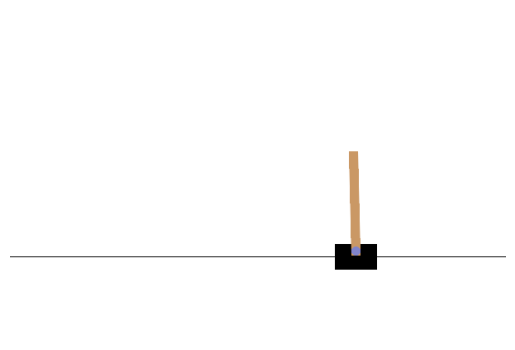

In [4]:
cp_photonic_ppo.evaluate()

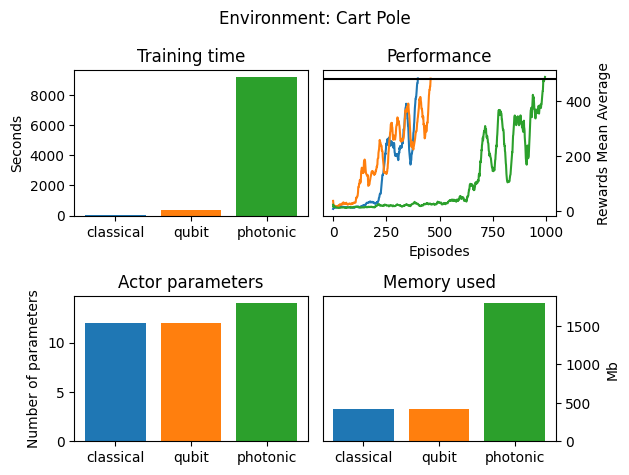

In [5]:
plot_results(env_name, qrl_results.get(env_name, {}), cp_config["mean_reward_stop"], methods=["classical", "qubit", "photonic"])

## 3 - Results on Lunar Lander

In [ ]:
# Create the environment
lunarlander_env = gym.make("LunarLander-v3", render_mode="rgb_array")
lunarlander_env.reset(seed=seed)
lunarlander_env.action_space.seed(seed)
lunarlander_env.observation_space.seed(seed)
env_name = "Lunar Lander"

# Create the config
ll_config = {
    "ae_hidden_dim": 64, "ae_output_dim": 3,
    "critic_intermediate_dim": 128,
    "minibatch_size": 64, "lr": 3e-4,
    "K": 4, "episode_update_frequency": 1, "mean_reward_lookback": 50, "mean_reward_stop": 220,
    "gamma": 0.99, "lambda": 0.98, "epsilon": 0.2, "entropy_coeff": 0.01, "print_steps_frequency": 100000
    }
ll_config["actor_intermediate_dim"] = 2
mode = "photonic"
train = True # ~ 10+ days if True

# Launch training
with MemoryTracker() as ll_photonic_stats:
    ll_photonic_ppo = PPO(
        AutoEncoderClass=AutoEncoder, 
        ActorClass=ActorPhotonicNN, 
        CriticClass=CriticNN, 
        env=lunarlander_env,
        env_name=env_name,
        env_config=ll_config, 
        mode=mode,
        device=device,
        results_folder=results_folder,
        results_filename=results_filename,
        memory_stats=ll_photonic_stats
        )

    if train:
        qrl_results = ll_photonic_ppo.run()
    else:
       load_weights(results_folder, ll_photonic_ppo, env_name, mode, device)
       qrl_results = load_results(os.path.join(results_folder, results_filename))


PPO training

Step 100000: mean reward = -193.72 (1:41:25.360585)

Step 200000: mean reward = -176.43 (1:41:49.133264)

Step 300000: mean reward = -119.26 (1:42:00.373319)

Step 400000: mean reward = -80.58 (1:41:43.725946)

Step 500000: mean reward = -99.65 (1:41:55.066692)

Step 600000: mean reward = -43.80 (1:41:54.062930)

Step 700000: mean reward = -47.04 (1:41:16.592512)

Step 800000: mean reward = -53.92 (1:42:12.036949)

Step 900000: mean reward = -68.17 (1:42:03.214717)

Step 1000000: mean reward = -81.28 (1:42:01.631571)

Step 1100000: mean reward = -42.67 (1:41:05.272031)

Step 1200000: mean reward = -55.57 (1:41:09.440148)

Step 1300000: mean reward = -62.55 (1:41:56.926518)

Step 1400000: mean reward = -86.32 (1:42:00.755055)

Step 1500000: mean reward = -33.57 (1:41:54.163524)

Step 1600000: mean reward = -46.89 (1:42:01.083076)

Step 1700000: mean reward = -31.37 (1:42:07.096717)

Step 1800000: mean reward = -30.66 (1:42:04.274517)

Step 1900000: mean reward = -25.38 (1

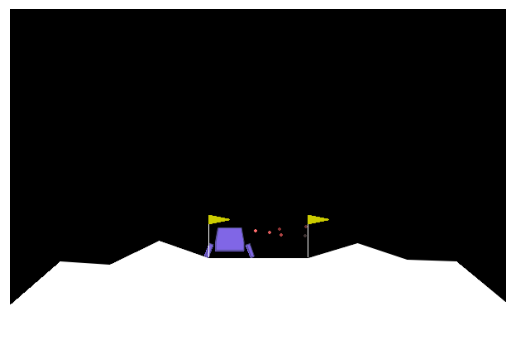

In [4]:
ll_photonic_ppo.evaluate()

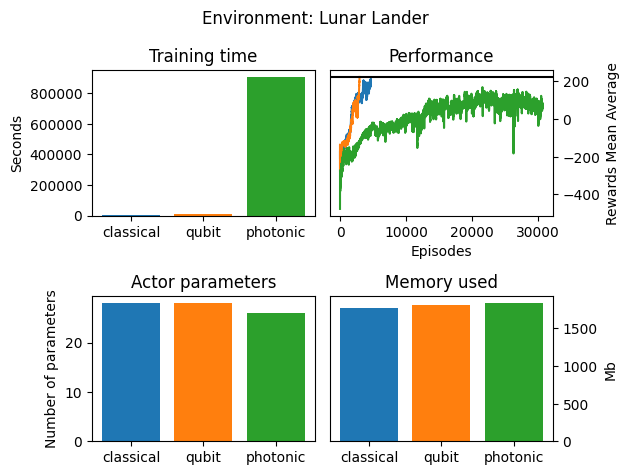

In [5]:
plot_results(env_name, qrl_results.get(env_name, {}), ll_config["mean_reward_stop"], methods=["classical", "qubit", "photonic"])

## 4 - Results on Maze

In [ ]:
# Create the environment
grid_size = 8
img_size = 64
maze_env = Maze(grid_size=grid_size, img_size=img_size)
maze_env.reset(seed=seed)
maze_env.action_space.seed(seed)
maze_env.observation_space.seed(seed)
env_name = "Maze"

# Create the config
m_config = {
    "ae_hidden_dim": [8, 16, 32, 64], "ae_output_dim": 16, 
    "ae_pretrain_epochs": 15000, "ae_pretrain_n_examples": 500000, "ae_pretrain_batchsize": 128,
    "critic_intermediate_dim": [8, 16, 32, 64],
    "minibatch_size": 128, "lr": 1e-4,
    "K": 8, "episode_update_frequency": 20, "mean_reward_lookback": 30, "mean_reward_stop": 0.8,
    "curriculum_levels": [ 
        # (inner_walls_min, inner_walls_max, max_wall_length, max_agent_distance_to_exit)
        (0, 0, 0, 1), # Level 1
        (0, 0, 0, 3), # Level 2
        (0, 0, 0, 5), # Level 3
        (1, 1, 4, 3), # Level 4
        (1, 1, 4, 5), # Level 5
        (2, 2, 8, 3), # Level 6
        (2, 2, 8, 5), # Level 7
        (3, 3, 8, 3), # Level 8
        (3, 3, 8, 5), # Level 9
        None],        # Level 10
    "gamma": 0.99, "lambda": 0.95, "epsilon": 0.2, "entropy_coeff": 0.01, "print_steps_frequency": 1000000
    }
custom_obs_shape = (img_size, img_size, 1)
m_config["actor_intermediate_dim"] = 2
mode = "photonic"
train_ae = False # ~ 20 hours if True
train = False # ~ X days if True

# Launch training
with MemoryTracker() as m_photonic_stats:
    m_photonic_ppo = MazePPO(
        AutoEncoderClass=ConvolutionalAE, 
        ActorClass=ActorPhotonicNN, 
        CriticClass=CriticCNN, 
        env=maze_env,
        env_name=env_name,
        env_config=m_config, 
        mode=mode,
        device=device,
        results_folder=results_folder,
        results_filename=results_filename,
        memory_stats=m_photonic_stats,
        custom_obs_shape=custom_obs_shape,
        train_ae = train_ae
        )
    
    if train:
        qrl_results = m_photonic_ppo.run()
    else:
       load_weights(results_folder, m_photonic_ppo, env_name, mode, device)
       qrl_results = load_results(os.path.join(results_folder, results_filename))


Loading ConvolutionalAE weights

Loading models' weights
Weights for ae do not exist !
Weights for actor do not exist !
Weights for critic do not exist !


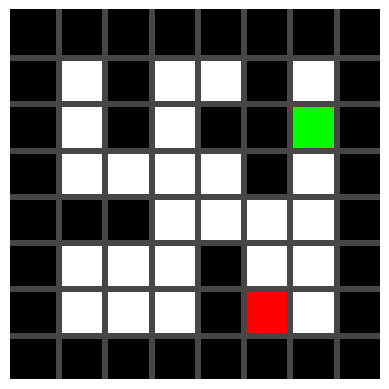

In [ ]:
m_photonic_ppo.evaluate()

Results for classical (Maze) don't exist !
Results for qubit (Maze) don't exist !
Results for photonic (Maze) don't exist !


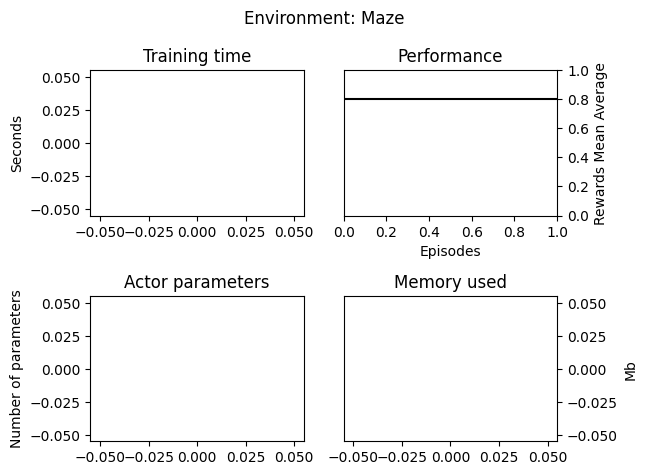

In [ ]:
plot_results(env_name, qrl_results.get(env_name, {}), m_config["mean_reward_stop"], methods=["classical", "qubit", "photonic"])

## 5 - Conclusion
___

The training time is the biggest limitation here, with the simulation taking much longer than the classical and qubit-based methods. Also, for the same amount of parameters, a lot more memory is used for the photonic simulation.

In the article, the authors used an alternative to the no-longer maintained Strawberry-Fields photonic library: [Piquasso](https://github.com/Budapest-Quantum-Computing-Group/piquasso). You can find more information about it in this article: ["Piquasso: A Photonic Quantum Computer Simulation Software Platform"](https://arxiv.org/pdf/2403.04006)